# Pipeline3D — ScanNet · text query → 3D object

Identical flow to `Pipeline3D_TUM.ipynb`, but the dataset adapter is the only
thing that changes: `load_scannet(SCENE_DIR)`. Everything downstream
(`Indexer`, `Search2D`, `ProjectTo3D`, `build_scene_cloud`, k3d) is
dataset-agnostic and untouched.

1. **Index** — `load_scannet(...)` → `FrameSet` → `Indexer.insert(...)`.
2. **Query** — `embed | retrieve | select | detect | rerank | project`, in one
   of two retrieval modes:
   - **`topk`** — legacy fixed-k: exactly `TOP_K_RETRIEVE` frames go to SAM.
   - **`dynamic`** — Otsu-sized pool over *all* frames + `SelectDiverse` picks
     `n_diverse` viewpoint-diverse frames for SAM.
3. **Visualise** — k3d: scene cloud + fused object (red) + 3D box.

## ScanNet layout

No ScanNet scene ships in this repo — download one and point `SCENE_DIR` at it.
The adapter expects the standard exported layout:

```
SCENE_DIR/
  color/{i}.jpg              # RGB frames  (e.g. 1296×968)
  depth/{i}.png             # 16-bit depth (e.g. 640×480)
  pose/{i}.txt              # 4×4 cam-to-world per frame
  intrinsic/intrinsic_depth.txt   # 4×4 depth intrinsics
```

**Resolution:** ScanNet colour and depth differ in size. `load_scannet`
handles this in the adapter — it resizes each colour frame to the depth grid
(cached under `color_aligned_<W>x<H>/`) and uses `intrinsic_depth.txt`, so the
returned `FrameSet` always has colour-res == depth-res and nothing downstream
needs resolution logic. `depth_scale=1000` (ScanNet) and the intrinsics come
straight from the loader.

## Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import torch
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import k3d

# ── ensure project root is on sys.path and is the working directory ──────────
PROJECT_ROOT = Path("__file__").resolve().parent.parent
if not (PROJECT_ROOT / "config.yaml").exists():
    PROJECT_ROOT = Path("__file__").resolve().parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Project root : {PROJECT_ROOT}")
print(f"Using device : {device}")

Project root : /usr/prakt/s0036/AppliedFoundationModels
Using device : cuda


## Dataset config

In [2]:
# Point this at a downloaded ScanNet scene directory (see the layout cell above).
SCENE_DIR  = "/storage/group/dataset_mirrors/scannet/scans/scene0011_00"
COLLECTION = "scannet_scene0011_00"

## Index

`load_scannet` reads intrinsics + `depth_scale` from the scene itself, aligns
colour to depth resolution (cached), and returns a `FrameSet`.

In [3]:
from src.utils.datasets import load_scannet
from src.index import Indexer, get_status
from src.utils.db import connect as db_connect
import yaml

cfg = yaml.safe_load(Path("config.yaml").read_text())
db  = db_connect(cfg["indexing"]["db_path"])

fs = load_scannet(SCENE_DIR)
print(f"Collection : {COLLECTION}")
print(f"Frames     : {len(fs):,}")
print(f"Intrinsics : {fs.intrinsics}  ·  depth_scale={fs.depth_scale}")

if COLLECTION in db.list_tables().tables:
    n_rows = db.open_table(COLLECTION).count_rows()
    print(f"'{COLLECTION}' already exists with {n_rows:,} rows — skipping indexing.")
else:
    print(f"Indexing '{COLLECTION}' …")
    idx = Indexer.from_config("config.yaml")
    job = idx.insert(
        fs.paths, COLLECTION,
        depth_paths=fs.depth_paths, poses=fs.poses,
        intrinsics=fs.intrinsics, depth_scale=fs.depth_scale,
    )
    status = get_status(job.job_id)
    print(f"Done — {status['processed']}/{status['total']} frames")

Collection : scannet_scene0011_00
Frames     : 2,374
Intrinsics : {'fx': 577.590698, 'fy': 578.729797, 'cx': 318.905426, 'cy': 242.683609}  ·  depth_scale=1000.0
'scannet_scene0011_00' already exists with 2,374 rows — skipping indexing.


## Build pipeline (SAM)

In [4]:
from src.query.pipeline import Search2D

pipeline = Search2D.from_config("config.yaml", detector="sam")
print("SAM pipeline ready (chain: embed | retrieve | select | detect | rerank | project).")

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

SAM pipeline ready (chain: embed | retrieve | select | detect | rerank | project).


## Query — mode A: fixed top-k (`topk`, legacy)

Retrieves exactly `TOP_K_RETRIEVE` frames by cosine similarity and runs SAM on
all of them — no thresholding, no diversity selection. Kept as the baseline;
the mode must be passed explicitly since the config default is now `dynamic`
(which ignores `TOP_K_RETRIEVE`).

> The 2D/3D visualisation cells below use whichever query cell ran last.

In [11]:
QUERY          = "table"   # ← change to anything
TOP_K_RETRIEVE = 25         # candidate pool fetched from LanceDB (topk mode only)
TOP_K_FINAL    = 10          # results kept after re-ranking (all are fused in 3D)

print(f"Running pipeline for: '{QUERY}' (mode: topk) …")
state = pipeline.invoke(
    query=QUERY,
    collection_id=COLLECTION,
    top_k_retrieve=TOP_K_RETRIEVE,
    top_k_final=TOP_K_FINAL,
    retrieval_mode="topk",      # legacy fixed-k; dynamic mode in the next cell
)

print(f"Retrieved : {len(state.retrieved)} candidates")
print(f"Detected  : {len(state.detected)} images")
print(f"Final hits: {len(state.results)}")
print(f"Projected : {len(state.projected)} fused 3D object(s)")

Running pipeline for: 'table' (mode: topk) …


Segmenting frames: 100%|██████████| 25/25 [00:42<00:00,  1.71s/frame]


Retrieved : 25 candidates
Detected  : 25 images
Final hits: 10
Projected : 1 fused 3D object(s)


## Query — mode B: dynamic k + viewpoint diversity (`dynamic`)

The new default mode replaces the fixed `TOP_K_RETRIEVE` with two stages:

1. **Dynamic pool** — *all* frames are scored and the pool is sized from the
   similarity histogram via tail-Otsu thresholding. The separability gate
   (η ≥ 0.75) detects queries for objects that aren't in the scene: below the
   gate the threshold would sit in noise, so retrieval falls back to a tiny
   top-`min_k` pool and flags `gated=True`.
2. **Viewpoint-diverse subset** — `SelectDiverse` estimates a coarse object
   position from each frame's look-at point (camera centre + optical axis ×
   robust central depth), computes each camera's viewing direction around it,
   and greedy farthest-point sampling keeps `N_DIVERSE` frames that see the
   object **from maximally different sides**. Only those frames reach SAM —
   the detector budget drops from `TOP_K_RETRIEVE` to `N_DIVERSE` while the
   3D fusion gets better multi-view coverage.

`state.retrieval_diag` records how the pool was formed (mode, threshold, η,
pool size, selected frame ids). Pool/gate knobs live in `config.yaml → query`.

In [14]:
N_DIVERSE = 25   # SAM budget: viewpoint-diverse frames selected from the pool

print(f"Running pipeline for: '{QUERY}' (mode: dynamic) …")
state = pipeline.invoke(
    query=QUERY,
    collection_id=COLLECTION,
    top_k_final=TOP_K_FINAL,
    retrieval_mode="dynamic",
    n_diverse=N_DIVERSE,
)

diag = state.retrieval_diag
print(f"Pool      : {diag.pool_size} / {diag.total_frames} frames   "
      f"(threshold={diag.threshold:.4f}, η={diag.separability:.3f}, gated={diag.gated})")
if diag.gated:
    print("            ⚠ η below gate — no distinct relevant cluster; "
          "the object is likely not in this scene (top-min_k fallback).")
print(f"Selected  : {diag.n_selected} viewpoint-diverse frames")
print(f"Detected  : {len(state.detected)} images")
print(f"Final hits: {len(state.results)}")
print(f"Projected : {len(state.projected)} fused 3D object(s)")

Running pipeline for: 'table' (mode: dynamic) …


Segmenting frames: 100%|██████████| 25/25 [00:41<00:00,  1.68s/frame]


Pool      : 400 / 2374 frames   (threshold=0.1084, η=0.794, gated=False)
Selected  : 25 viewpoint-diverse frames
Detected  : 25 images
Final hits: 10
Projected : 1 fused 3D object(s)


## 2D results

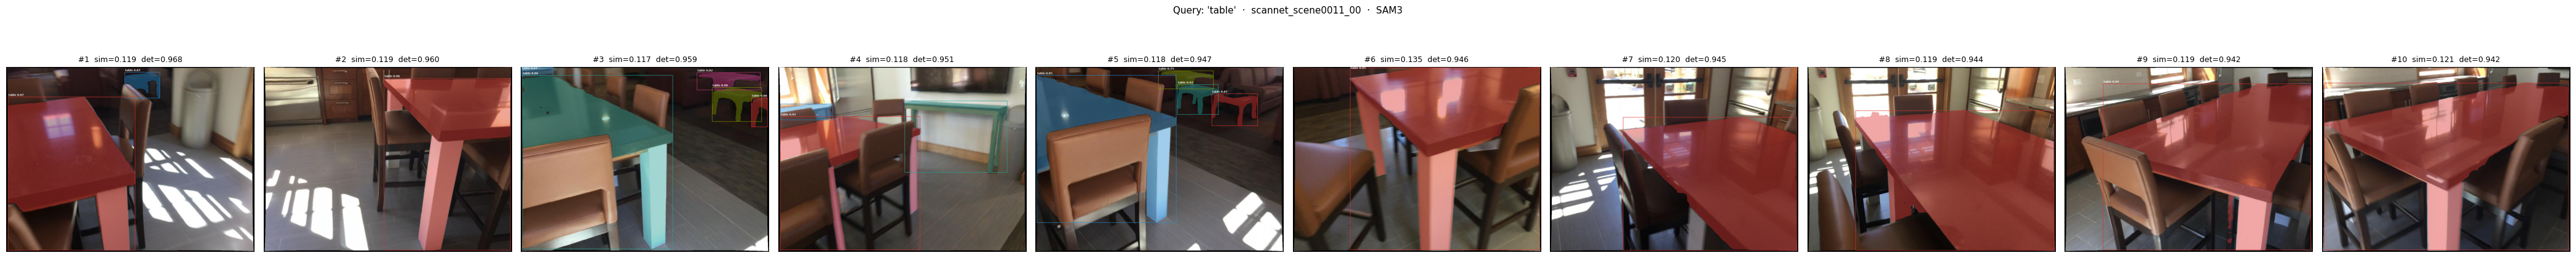

In [15]:
# ── 2D results: SAM mask overlays + boxes (same helper as Pipeline.ipynb) ─────
PALETTE = [
    (220, 50, 47), (38, 139, 210), (42, 161, 152), (133, 153, 0),
    (211, 54, 130), (181, 137, 0), (108, 113, 196), (203, 75, 22),
]
MASK_ALPHA = 110


def annotate_image(img, masks, boxes, scores, label):
    canvas = img.convert("RGBA")
    for i, mask in enumerate(masks or []):
        color = PALETTE[i % len(PALETTE)]
        mask_np = mask.cpu().numpy().astype(np.uint8)
        overlay = np.zeros((*mask_np.shape, 4), dtype=np.uint8)
        overlay[mask_np > 0] = [*color, MASK_ALPHA]
        canvas = Image.alpha_composite(canvas, Image.fromarray(overlay, "RGBA"))
    draw = ImageDraw.Draw(canvas)
    try:
        font = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", size=14)
    except OSError:
        font = ImageFont.load_default()
    for i, (score, box) in enumerate(zip(scores, boxes)):
        color = PALETTE[i % len(PALETTE)]
        x0, y0, x1, y1 = [int(v) for v in box.tolist()]
        draw.rectangle([x0, y0, x1, y1], outline=(*color, 255), width=2)
        draw.text((x0 + 3, max(y0 - 18, 0)), f"{label[:12]} {float(score):.2f}",
                  fill=(255, 255, 255, 255), font=font)
    return canvas.convert("RGB")


n = len(state.results)
fig, axes = plt.subplots(1, n, figsize=(n * 4.2, 4.5), squeeze=False)
for rank, (ax, hit) in enumerate(zip(axes[0], state.results), start=1):
    annotated = annotate_image(Image.open(hit.path).convert("RGB"),
                               hit.masks, hit.boxes, hit.scores, QUERY)
    ax.imshow(np.array(annotated))
    ax.set_title(f"#{rank}  sim={hit.similarity_score:.3f}  det={hit.detection_score:.3f}",
                 fontsize=9)
    ax.axis("off")
plt.suptitle(f"Query: '{QUERY}'  ·  {COLLECTION}  ·  SAM3", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 3D result

`build_scene_cloud(fs, ...)` reconstructs the scene; `state.projected[0]` is the
fused object. k3d shows scene + object (red) + box.

In [16]:
from src.utils.geometry import build_scene_cloud, aabb_corners

SCENE_N_FRAMES = 250   # full frames back-projected for the background cloud
VOXEL          = 0.02  # metres — downsample grid for both clouds


def pack_rgb(colors):
    """Pack a uint8 (N, 3) RGB array into k3d's uint32 0xRRGGBB colours."""
    c = np.asarray(colors, dtype=np.uint32)
    return (c[:, 0] << 16) | (c[:, 1] << 8) | c[:, 2]


# Background scene cloud (reusable helper — same back-projection as the object).
scene_pts, scene_col = build_scene_cloud(fs, n_frames=SCENE_N_FRAMES, voxel=VOXEL)
print(f"Scene cloud: {len(scene_pts):,} points")

obj = state.projected[0]   # the single fused object (cleaned cloud + world AABB)
print(f"Object '{QUERY}': {len(obj.points):,} points  ·  bbox=\n{obj.bbox}")

plot = k3d.plot(grid_visible=False, camera_auto_fit=True)
plot += k3d.points(
    scene_pts.astype(np.float32),
    colors=pack_rgb(scene_col) if scene_col is not None else None,
    point_size=VOXEL, shader="flat", name="scene",
)
plot += k3d.points(
    obj.points.astype(np.float32),
    color=0xff0000, point_size=VOXEL * 1.5, shader="flat", name=f"object: {QUERY}",
)
if obj.bbox is not None:
    corners = aabb_corners(obj.bbox).astype(np.float32)
    EDGES = np.array([[0,1],[1,2],[2,3],[3,0],[4,5],[5,6],[6,7],[7,4],
                      [0,4],[1,5],[2,6],[3,7]], dtype=np.uint32)
    plot += k3d.lines(corners, indices=EDGES, indices_type="segment",
                      color=0x00ff00, width=0.01, name="bbox")
plot.display()

Scene cloud: 1,514,254 points
Object 'table': 9,065 points  ·  bbox=
[[3.940491   1.7455615  0.17353225]
 [5.08005    3.500502   0.9281552 ]]


/usr/prakt/s0036/AppliedFoundationModels/.venv/lib/python3.12/site-packages/traittypes/traittypes.py:98: UserWarning: Given trait value dtype "uint32" does not match required type "float32". A coerced copy has been created.
  warnings.warn(


Output()